In [33]:
import os
import subprocess

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms, datasets as dsets

%matplotlib inline
torch.manual_seed(0)

In [34]:
print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.12.0+cpu
numpy: 2.2.6


In [35]:
# Reshape to (H, W) before imshow — channel dim must be dropped for grayscale display
def show_data(sample, shape=(28, 28)):
    img, label = sample
    plt.imshow(img.numpy().reshape(shape), cmap='gray')
    plt.title(f'y = {label}')
    plt.axis('off')
    plt.show()

In [36]:
# Wrapping shell commands in a function keeps download logic explicit and re-runnable
def exec_cmd(cmd):
    result = subprocess.run(cmd, shell=True, check=True,
                            capture_output=True, text=True)
    if result.stdout:
        print(result.stdout)
    return result

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

def download_image_data():
    img_url = ('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud'
               '/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork'
               '/labs/Week1/data/img.tar.gz')
    csv_url = ('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud'
               '/IBMDeveloperSkillsNetwork-DL0110EN-SkillsNetwork'
               '/labs/Week1/data/index.csv')

    exec_cmd(f'wget -q {img_url}  -O {DATA_DIR}/img.tar.gz')
    exec_cmd(f'tar  -xf {DATA_DIR}/img.tar.gz -C {DATA_DIR}/')
    exec_cmd(f'wget -q {csv_url} -O {DATA_DIR}/index.csv')
    print('Download complete.')

download_image_data()

Download complete.


In [37]:
# Column 0 = class label, column 1 = image filename
csv_path = os.path.join(DATA_DIR, 'index.csv')
index_df = pd.read_csv(csv_path)
index_df.head()

,category,image
0,Ankle boot,img/fashion0.png
1,T-shirt,img/fashion1.png
2,T-shirt,img/fashion2.png
3,Dress,img/fashion3.png
4,T-shirt,img/fashion4.png


In [38]:
print('Total samples:', index_df.shape[0])
print('File name [0]:', index_df.iloc[0, 1])
print('Class    [0]:', index_df.iloc[0, 0])

Total samples: 60000
File name [0]: img/fashion0.png
Class    [0]: Ankle boot


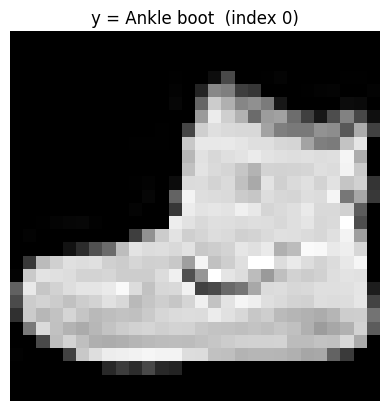

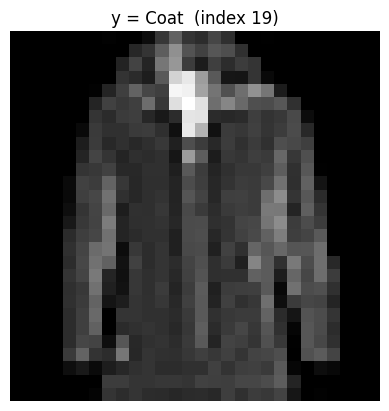

In [39]:
# PIL is the bridge between image files on disk and PyTorch tensors via ToTensor()
for idx in [0, 19]:
    img_path = os.path.join(DATA_DIR, index_df.iloc[idx, 1])
    image    = Image.open(img_path)
    label    = index_df.iloc[idx, 0]

    plt.imshow(image, cmap='gray', vmin=0, vmax=255)
    plt.title(f'y = {label}  (index {idx})')
    plt.axis('off')
    plt.show()

In [40]:
# Subclass Dataset and implement __len__ + __getitem__ — DataLoader requires both
# transform is applied lazily inside __getitem__ so raw data stays unchanged
class ImageDataset(Dataset):

    def __init__(self, csv_file, data_dir, transform=None):
        self.data_dir  = data_dir
        self.transform = transform
        df = pd.read_csv(os.path.join(data_dir, csv_file))

        # index.csv may list more entries than images on disk (partial download)
        # drop rows whose image file is missing so __getitem__ never hits a dead path
        exists   = df.iloc[:, 1].apply(lambda f: os.path.isfile(os.path.join(data_dir, f)))
        self.df  = df[exists].reset_index(drop=True)
        self.len = len(self.df)

        # Image.open is lazy — .size only parses the file header, no pixel data loaded
        # sizes stores (width, height) per image, matching PIL's convention
        self.sizes = []
        for i in range(self.len):
            img_path = os.path.join(data_dir, self.df.iloc[i, 1])
            with Image.open(img_path) as img:
                self.sizes.append(img.size)

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx, 1])
        image    = Image.open(img_path)
        label    = self.df.iloc[idx, 0]

        if self.transform:
            image = self.transform(image)
        return image, label

In [41]:
# Without a transform the dataset returns PIL Image objects — useful for quick inspection
raw_dataset = ImageDataset(csv_file='index.csv', data_dir=DATA_DIR)
print('Length          :', len(raw_dataset))
print('Type of image   :', type(raw_dataset[0][0]))
print('Label [0]       :', raw_dataset[0][1])
print('Size  [0] (W,H) :', raw_dataset.sizes[0])
print('All sizes       :', raw_dataset.sizes[:5], '...')
print('Unique sizes    :', set(raw_dataset.sizes))

Length          : 101
Type of image   : <class 'PIL.PngImagePlugin.PngImageFile'>
Label [0]       : Ankle boot
Size  [0] (W,H) : (28, 28)
All sizes       : [(28, 28), (28, 28), (28, 28), (28, 28), (28, 28)] ...
Unique sizes    : {(28, 28)}


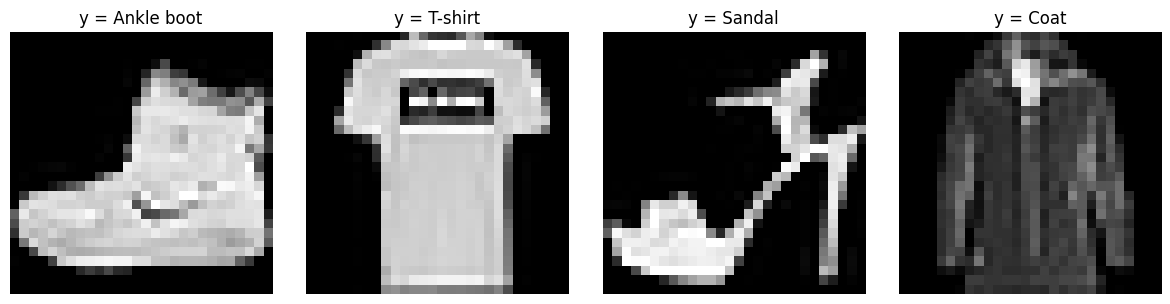

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, idx in zip(axes, [0, 1, 9, 19]):
    img, label = raw_dataset[idx]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'y = {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [43]:
# torchvision.datasets.MNIST handles downloading and loading automatically
# ToTensor() converts PIL Image [0, 255] to float tensor [0.0, 1.0]
mnist_dataset = dsets.MNIST(
    root='./data',
    download=True,
    transform=transforms.ToTensor()
)

In [44]:
print('Total samples   :', len(mnist_dataset))
print('Type of element :', type(mnist_dataset[0]))
print('Image shape     :', mnist_dataset[0][0].shape)
print('Image dtype     :', mnist_dataset[0][0].dtype)
print('Label           :', mnist_dataset[0][1])

Total samples   : 60000
Type of element : <class 'tuple'>
Image shape     : torch.Size([1, 28, 28])
Image dtype     : torch.float32
Label           : 5


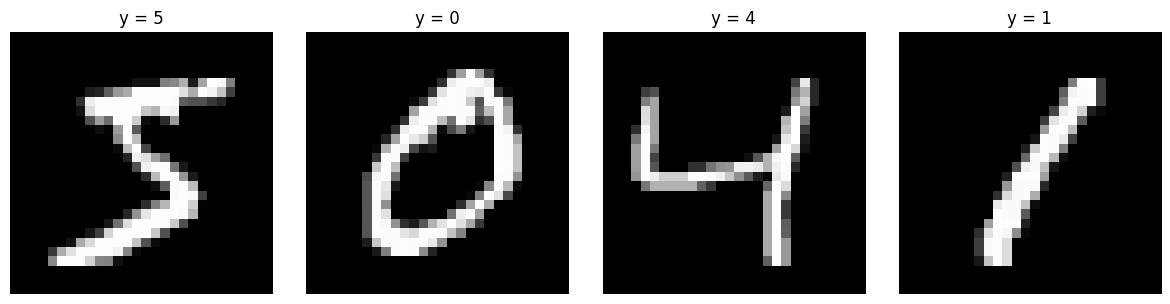

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, idx in zip(axes, [0, 1, 2, 3]):
    img, label = mnist_dataset[idx]
    ax.imshow(img.numpy().reshape(28, 28), cmap='gray')
    ax.set_title(f'y = {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Custom shape after CenterCrop(20): torch.Size([1, 20, 20])
MNIST  shape after CenterCrop(20): torch.Size([1, 20, 20])


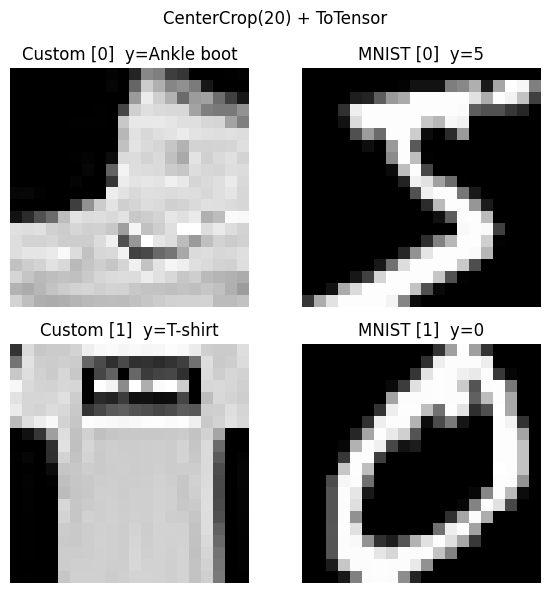

In [46]:
# CenterCrop(20) trims the image to a 20x20 square from the centre
# Compose chains transforms left-to-right — ToTensor must come last
crop_transform = transforms.Compose([
    transforms.CenterCrop(20),
    transforms.ToTensor(),
])

crop_custom = ImageDataset(csv_file='index.csv', data_dir=DATA_DIR, transform=crop_transform)
crop_mnist  = dsets.MNIST(root='./data', download=True, transform=crop_transform)

print('Custom shape after CenterCrop(20):', crop_custom[0][0].shape)
print('MNIST  shape after CenterCrop(20):', crop_mnist[0][0].shape)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for col, (ds, title) in enumerate([(crop_custom, 'Custom'), (crop_mnist, 'MNIST')]):
    for row, idx in enumerate([0, 1]):
        img, label = ds[idx]
        axes[row, col].imshow(img.numpy().reshape(20, 20), cmap='gray')
        axes[row, col].set_title(f'{title} [{idx}]  y={label}')
        axes[row, col].axis('off')
plt.suptitle('CenterCrop(20) + ToTensor')
plt.tight_layout()
plt.show()

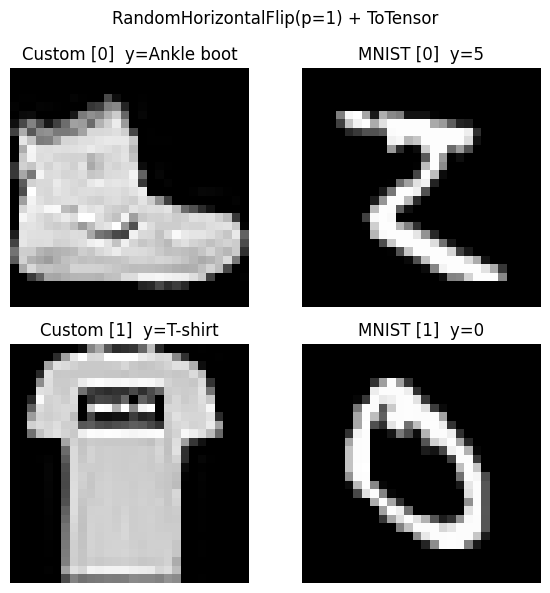

In [47]:
# p=1 forces the flip every time, making the result deterministic for inspection
hflip_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor(),
])

hflip_custom = ImageDataset(csv_file='index.csv', data_dir=DATA_DIR, transform=hflip_transform)
hflip_mnist  = dsets.MNIST(root='./data', download=True, transform=hflip_transform)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for col, (ds, title) in enumerate([(hflip_custom, 'Custom'), (hflip_mnist, 'MNIST')]):
    for row, idx in enumerate([0, 1]):
        img, label = ds[idx]
        shape = img.shape[-2:]
        axes[row, col].imshow(img.numpy().reshape(shape), cmap='gray')
        axes[row, col].set_title(f'{title} [{idx}]  y={label}')
        axes[row, col].axis('off')
plt.suptitle('RandomHorizontalFlip(p=1) + ToTensor')
plt.tight_layout()
plt.show()

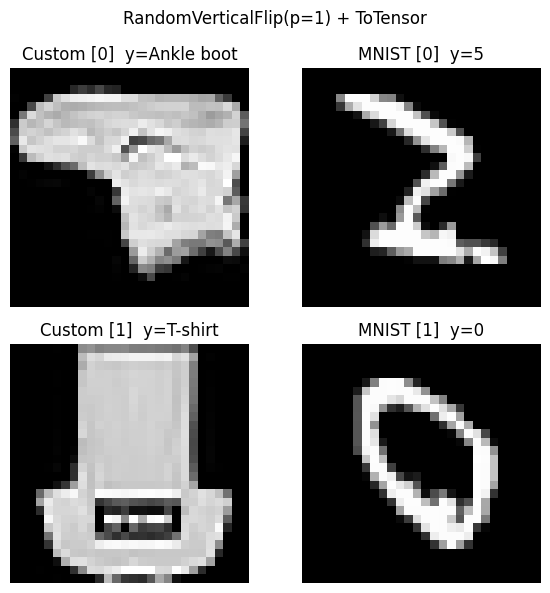

In [48]:
vflip_transform = transforms.Compose([
    transforms.RandomVerticalFlip(p=1),
    transforms.ToTensor(),
])

vflip_custom = ImageDataset(csv_file='index.csv', data_dir=DATA_DIR, transform=vflip_transform)
vflip_mnist  = dsets.MNIST(root='./data', download=True, transform=vflip_transform)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for col, (ds, title) in enumerate([(vflip_custom, 'Custom'), (vflip_mnist, 'MNIST')]):
    for row, idx in enumerate([0, 1]):
        img, label = ds[idx]
        shape = img.shape[-2:]
        axes[row, col].imshow(img.numpy().reshape(shape), cmap='gray')
        axes[row, col].set_title(f'{title} [{idx}]  y={label}')
        axes[row, col].axis('off')
plt.suptitle('RandomVerticalFlip(p=1) + ToTensor')
plt.tight_layout()
plt.show()

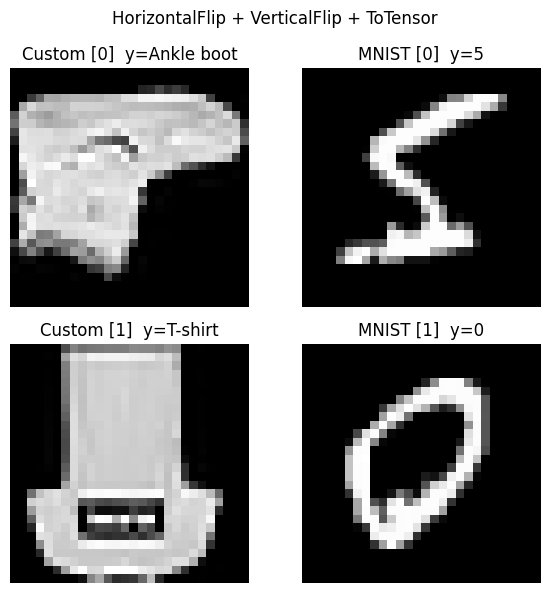

In [49]:
# Compose is not commutative — order of transforms changes the result
both_flips = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.RandomVerticalFlip(p=1),
    transforms.ToTensor(),
])

flipped_custom = ImageDataset(csv_file='index.csv', data_dir=DATA_DIR, transform=both_flips)
flipped_mnist  = dsets.MNIST(root='./data', download=True, transform=both_flips)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for col, (ds, title) in enumerate([(flipped_custom, 'Custom'), (flipped_mnist, 'MNIST')]):
    for row, idx in enumerate([0, 1]):
        img, label = ds[idx]
        shape = img.shape[-2:]
        axes[row, col].imshow(img.numpy().reshape(shape), cmap='gray')
        axes[row, col].set_title(f'{title} [{idx}]  y={label}')
        axes[row, col].axis('off')
plt.suptitle('HorizontalFlip + VerticalFlip + ToTensor')
plt.tight_layout()
plt.show()

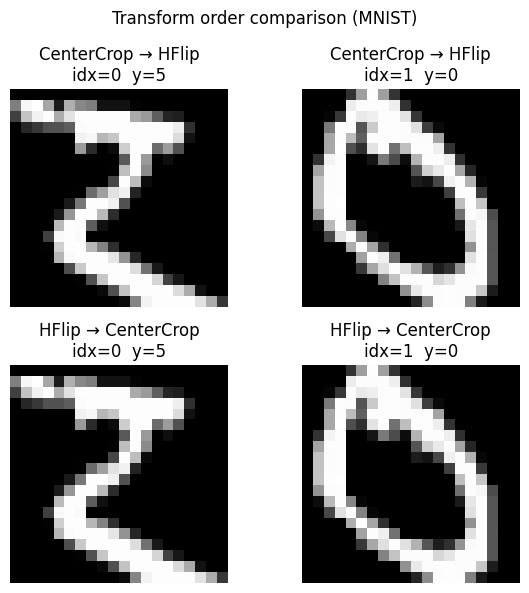

In [50]:
# Crop before flip vs flip before crop — visually identical here but matters for non-square crops
crop_then_flip = transforms.Compose([
    transforms.CenterCrop(20),
    transforms.RandomHorizontalFlip(p=1),
    transforms.ToTensor(),
])
flip_then_crop = transforms.Compose([
    transforms.RandomHorizontalFlip(p=1),
    transforms.CenterCrop(20),
    transforms.ToTensor(),
])

mnist_cf = dsets.MNIST(root='./data', download=True, transform=crop_then_flip)
mnist_fc = dsets.MNIST(root='./data', download=True, transform=flip_then_crop)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for row, (ds, title) in enumerate([(mnist_cf, 'CenterCrop → HFlip'),
                                    (mnist_fc, 'HFlip → CenterCrop')]):
    for col, idx in enumerate([0, 1]):
        img, label = ds[idx]
        axes[row, col].imshow(img.numpy().reshape(20, 20), cmap='gray')
        axes[row, col].set_title(f'{title}\nidx={idx}  y={label}')
        axes[row, col].axis('off')
plt.suptitle('Transform order comparison (MNIST)')
plt.tight_layout()
plt.show()